In [40]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

In [41]:
w1 = np.random.randn(4, 2) * 0.01
b1 = np.zeros(4)
w2 = np.random.randn(4, 4) * 0.01
b2 = np.zeros(4)
w3 = np.random.randn(3, 4) * 0.01
b3 = np.zeros(3)

In [42]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [43]:
def softmax(z):
    zshift = z - np.max(z)
    expz = np.exp(zshift)
    return expz / np.sum(expz)

In [44]:
x = np.random.randn(2)
yt = np.array([0, 1, 0])

a0 = x
z1 = w1 @ a0 + b1
a1 = sigmoid(z1)

z2 = w2 @ a1 + b2
a2 = sigmoid(z2)

z3 = w3 @ a2 + b3
a3 = softmax(z3)
a3

array([0.33635845, 0.33014477, 0.33349677])

In [45]:
np.sum(a3)

np.float64(0.9999999999999999)

In [46]:
del3 = a3 - yt
spz2 = a2 * (1 - a2)
del2 = (w3.T @ del3) * spz2
spz1 = a1 * (1 - a1)
del1 = (w2.T @ del2) * spz1

In [47]:
np.shape(del3)

(3,)

In [48]:
np.shape(del2)

(4,)

In [49]:
np.shape(del1)

(4,)

In [50]:
dw3 = np.outer(del3, a2.T)
db3 = del3
dw2 = np.outer(del2, a1.T)
db2 = del2
dw1 = np.outer(del1, a0.T)
db1 = del1

In [51]:
np.shape(dw1)

(4, 2)

In [52]:
eta = 0.1
x = np.random.randn(2)
yt = np.array([0, 1, 0])
a0 = x
losses = []

for i in range(100):
    z1 = w1 @ a0 + b1
    a1 = sigmoid(z1)
    
    z2 = w2 @ a1 + b2
    a2 = sigmoid(z2)
    
    z3 = w3 @ a2 + b3
    a3 = softmax(z3)

    del3 = a3 - yt
    spz2 = a2 * (1 - a2)
    del2 = (w3.T @ del3) * spz2
    spz1 = a1 * (1 - a1)
    del1 = (w2.T @ del2) * spz1
    dw3 = np.outer(del3, a2.T)
    db3 = del3
    dw2 = np.outer(del2, a1.T)
    db2 = del2
    dw1 = np.outer(del1, a0.T)
    db1 = del1
    w3 = w3 - eta * dw3
    b3 = b3 - eta * db3
    w2 = w2 - eta * dw2
    b2 = b2 - eta * db2
    w1 = w1 - eta * dw1
    b1 = b1 - eta * db1
    loss = -np.sum(yt * np.log(np.clip(a3, 1e-7, 1)))
    losses.append(loss)
losses

[np.float64(1.1082234901365648),
 np.float64(0.9783643766830246),
 np.float64(0.8657968069183523),
 np.float64(0.768735564270821),
 np.float64(0.6853086051538755),
 np.float64(0.6136843723000379),
 np.float64(0.5521599255043701),
 np.float64(0.49921006825312764),
 np.float64(0.45350532606291005),
 np.float64(0.4139088155020989),
 np.float64(0.3794609358545672),
 np.float64(0.3493584708727931),
 np.float64(0.32293234403767773),
 np.float64(0.2996264353478013),
 np.float64(0.27897861911614813),
 np.float64(0.26060441776350873),
 np.float64(0.24418324323503743),
 np.float64(0.22944699158719684),
 np.float64(0.2161706778949271),
 np.float64(0.20416478943411642),
 np.float64(0.19326905961956833),
 np.float64(0.1833474032001531),
 np.float64(0.17428379394853755),
 np.float64(0.1659789042857818),
 np.float64(0.15834735979104161),
 np.float64(0.15131548982981394),
 np.float64(0.14481947884734614),
 np.float64(0.13880384180480118),
 np.float64(0.1332201624637629),
 np.float64(0.1280260454034967

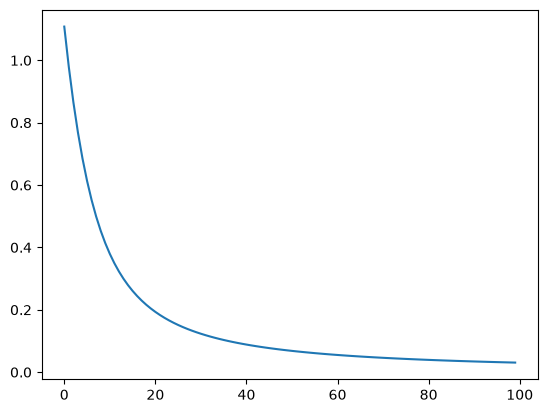

In [53]:
plt.plot(losses)

In [63]:
np.random.seed(33550336)
x0 = np.random.randn(50, 2) * 0.5 + np.array([2, 2])
x1 = np.random.randn(50, 2) * 0.5 + np.array([-2, 2])
x2 = np.random.randn(50, 2) * 0.5 + np.array([0, -2])
X = np.vstack([x0, x1, x2]) 
y = np.array([0]*50 + [1]*50 + [2]*50)
idx = np.random.permutation(150)
X = X[idx]
y = y[idx]
w1 = np.random.randn(4, 2) * 0.01
b1 = np.zeros(4)
w2 = np.random.randn(4, 4) * 0.01
b2 = np.zeros(4)
w3 = np.random.randn(3, 4) * 0.01
b3 = np.zeros(3)

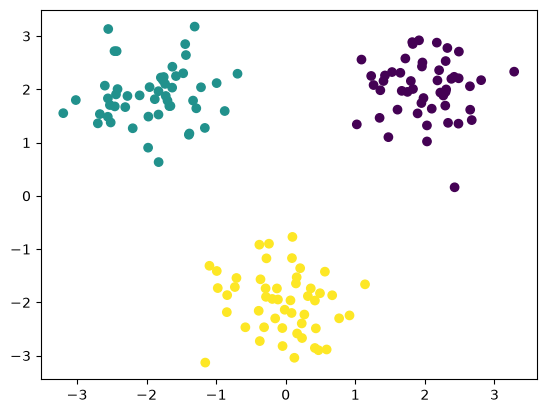

In [59]:
plt.scatter(X[:,0], X[:, 1], c = y)

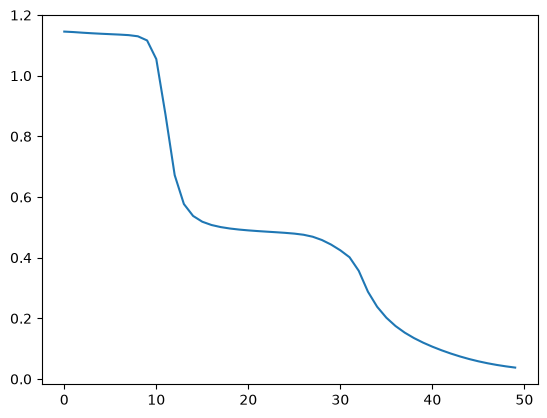

In [62]:
nepoch = 50
eta = 0.1
el = []


for j in range(nepoch):
    tl = 0
    for i in range(150):
        xi = X[i]
        lab = y[i]
        yon = np.zeros(3)
        yon[lab] = 1
        a0 = xi
        z1 = w1 @ a0 + b1
        a1 = sigmoid(z1)
        z2 = w2 @ a1 + b2
        a2 = sigmoid(z2)
        z3 = w3 @ a2 + b3
        a3 = softmax(z3)
        l = -np.sum(yon * np.log(a3))
        tl += l
        del3 = a3 - yon
        spz2 = a2 * (1 - a2)
        del2 = (w3.T @ del3) * spz2
        spz1 = a1 * (1 - a1)
        del1 = (w2.T @ del2) * spz1
        dw3 = np.outer(del3, a2.T)
        db3 = del3
        dw2 = np.outer(del2, a1.T)
        db2 = del2
        dw1 = np.outer(del1, a0.T)
        db1 = del1
        w3 = w3 - eta * dw3
        b3 = b3 - eta * db3
        w2 = w2 - eta * dw2
        b2 = b2 - eta * db2
        w1 = w1 - eta * dw1
        b1 = b1 - eta * db1
    avgl = tl/150
    el.append(avgl)

plt.plot(el)

In [89]:
w1 = np.random.randn(4, 2) * 0.01
b1 = np.zeros(4)
w2 = np.random.randn(4, 4) * 0.01
b2 = np.zeros(4)
w3 = np.random.randn(3, 4) * 0.01
b3 = np.zeros(3)

In [90]:
w1[0, 0]

np.float64(-0.004025674766875283)

In [99]:
yt = np.array([0, 1, 0])
x = np.random.randn(2)
lp = w1.copy()
lm = w1.copy()
a0 = x
z1 = w1 @ a0 + b1
a1 = sigmoid(z1)

z2 = w2 @ a1 + b2
a2 = sigmoid(z2)

z3 = w3 @ a2 + b3
a3 = softmax(z3)

del3 = a3 - yt
spz2 = a2 * (1 - a2)
del2 = (w3.T @ del3) * spz2
spz1 = a1 * (1 - a1)
del1 = (w2.T @ del2) * spz1
dw3 = np.outer(del3, a2.T)
db3 = del3
dw2 = np.outer(del2, a1.T)
db2 = del2
dw1 = np.outer(del1, a0.T)
db1 = del1

save = dw1.copy()

In [100]:
yt = np.array([0, 1, 0])
lp = w1.copy()
lp[0,0 ] += 1e-5
a0 = x
z1 = lp @ a0 + b1
a1 = sigmoid(z1)

z2 = w2 @ a1 + b2
a2 = sigmoid(z2)

z3 = w3 @ a2 + b3
a3 = softmax(z3)

del3 = a3 - yt
spz2 = a2 * (1 - a2)
del2 = (w3.T @ del3) * spz2
spz1 = a1 * (1 - a1)
del1 = (w2.T @ del2) * spz1
dw3 = np.outer(del3, a2.T)
db3 = del3
dw2 = np.outer(del2, a1.T)
db2 = del2
dw1 = np.outer(del1, a0.T)
db1 = del1

lplus = -np.sum(yt * np.log(np.clip(a3, 1e-7, 1)))

In [103]:
yt = np.array([0, 1, 0])
lm = w1.copy()
lm[0,0] -= 1e-5
a0 = x
z1 = lm @ a0 + b1
a1 = sigmoid(z1)

z2 = w2 @ a1 + b2
a2 = sigmoid(z2)

z3 = w3 @ a2 + b3
a3 = softmax(z3)

del3 = a3 - yt
spz2 = a2 * (1 - a2)
del2 = (w3.T @ del3) * spz2
spz1 = a1 * (1 - a1)
del1 = (w2.T @ del2) * spz1
dw3 = np.outer(del3, a2.T)
db3 = del3
dw2 = np.outer(del2, a1.T)
db2 = del2
dw1 = np.outer(del1, a0.T)
db1 = del1

lminus = -np.sum(yt * np.log(np.clip(a3, 1e-7, 1)))

In [104]:
(lplus-lminus)/(2e-5)

np.float64(5.1510462562021075e-06)

In [105]:
save[0,0]

np.float64(5.151040728903054e-06)